In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [79]:
df = pd.read_csv('Video_Games.csv')
df.head()

,index,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#get the shape of the datafram (rows, columns)
df.shape

In [ ]:
#get information on the dataset: missing values , type of columns ...
df.info()

In [ ]:
# sum of all the null values
df.isnull().sum()

In [55]:
#HOW MANY GAMES HAVE BOTH CRITIC AND USER SCORES AVAILABLE ?
games_with_scores = df[['Critic_Score', 'User_Score']].dropna()
games_with_scores_count = games_with_scores.shape[0]
games_with_scores_count

df.describe()

,index,Year_of_Release,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Count
count,16928.000000,16655.00000,16928.000000,16928.000000,16928.000000,16928.000000,16928.000000,8260.000000,8260.000000,7718.000000
mean,8463.500000,2006.48532,0.266390,0.146850,0.078170,0.047861,0.539520,69.037893,26.428692,163.269629
std,4886.837014,5.88289,0.814326,0.504585,0.308756,0.186675,1.550545,13.943198,18.989929,562.786746
min,0.000000,1980.00000,0.000000,0.000000,0.000000,0.000000,0.010000,13.000000,3.000000,4.000000
25%,4231.750000,2003.00000,0.000000,0.000000,0.000000,0.000000,0.060000,60.000000,12.000000,10.000000
50%,8463.500000,2007.00000,0.080000,0.020000,0.000000,0.010000,0.170000,71.000000,22.000000,25.000000
75%,12695.250000,2010.00000,0.240000,0.110000,0.040000,0.040000,0.490000,79.000000,36.000000,82.000000
max,16927.000000,2020.00000,41.360000,28.960000,10.220000,10.570000,82.530000,98.000000,113.000000,10665.000000


In [ ]:
#pd.set_option('display.max_rows', None)
#df

<function matplotlib.pyplot.show(close=None, block=None)>

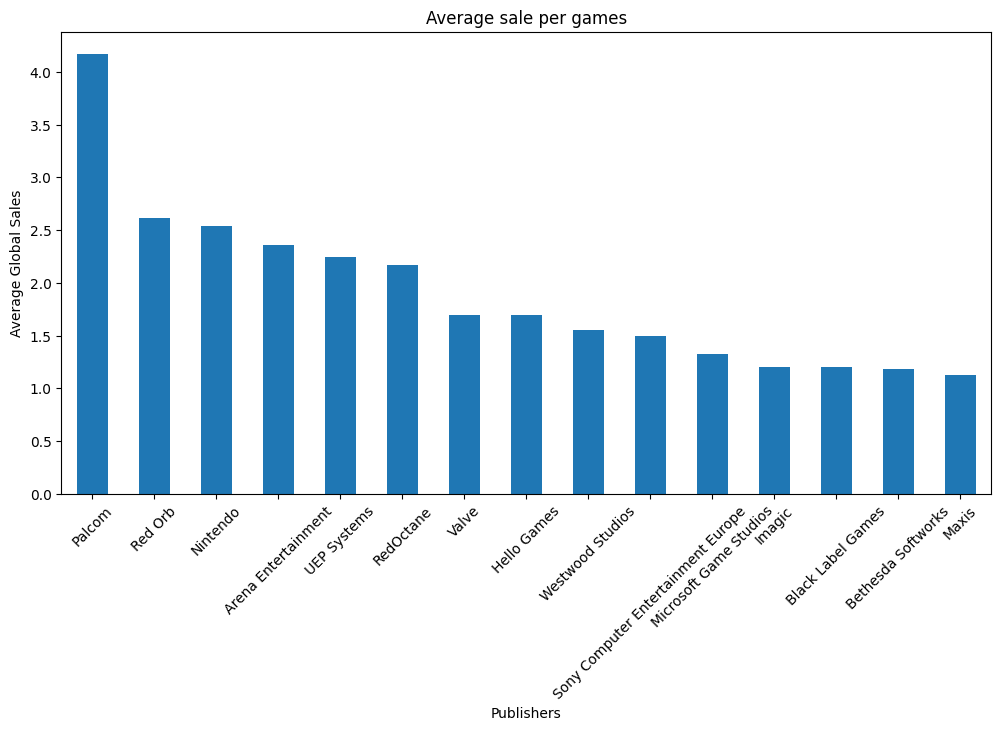

In [120]:
#Which publisher has the highest average sale per games?

average_sale_per_games = df.groupby('Publisher')['Global_Sales'].mean().sort_values(ascending=False)


plt.figure(figsize=(12,6))
average_sale_per_games.head(15).plot(kind="bar")
plt.title("Average sale per games")
plt.xlabel('Publishers')
plt.ylabel('Average Global Sales')
plt.xticks(rotation = 45)
plt.show

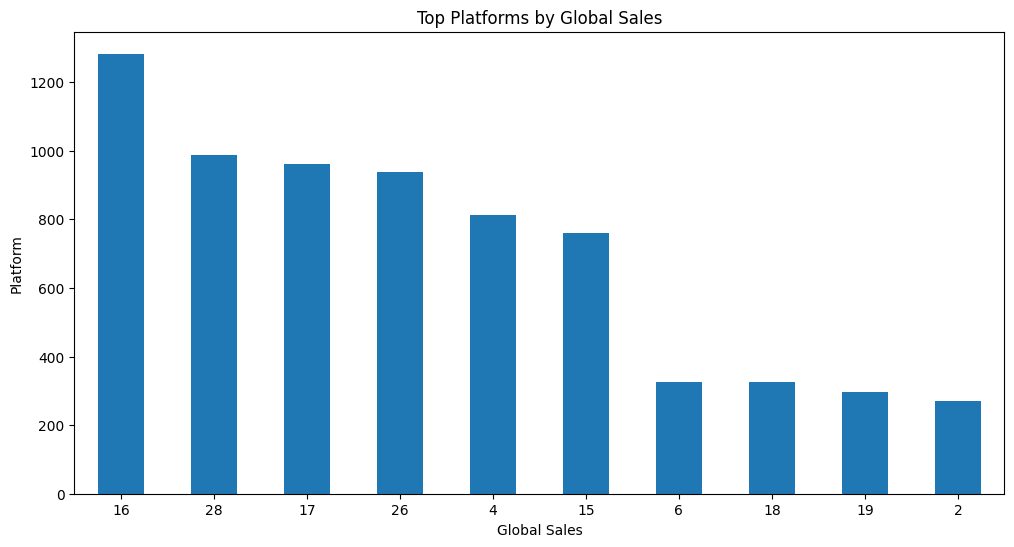

(Platform        0
 Global_Sales    0
 dtype: int64,
 Platform
 16    1283.08
 28     988.36
 17     962.71
 26     937.27
 4      813.86
 15     759.88
 6      327.11
 18     324.48
 19     298.02
 2      271.21
 Name: Global_Sales, dtype: float64)

In [118]:
#WHAT PLATFORMS HAVE THE HIGHEST GLOBAL SALES?
missing_values_platforms = df[['Platform', 'Global_Sales']].isnull().sum()

platform_sales = video_games_cleaned_df.groupby('Platform')['Global_Sales'].sum().sort_values(ascending = False)

#difplay the top platforms by global sales
top_platforms = platform_sales.head(10)


#visualisation
plt.figure(figsize=(12,6))
top_platforms.plot(kind = 'bar')
plt.title('Top Platforms by Global Sales')
plt.xlabel('Global Sales')
plt.ylabel('Platform')
plt.xticks(rotation = 0)
plt.show()

missing_values_platforms, top_platforms

/var/folders/ky/wtg1vw412sz5kfbftp83kvn40000gn/T/ipykernel_20832/3840001893.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(best_selling_games, labels = best_selling_games.index.astype(int))


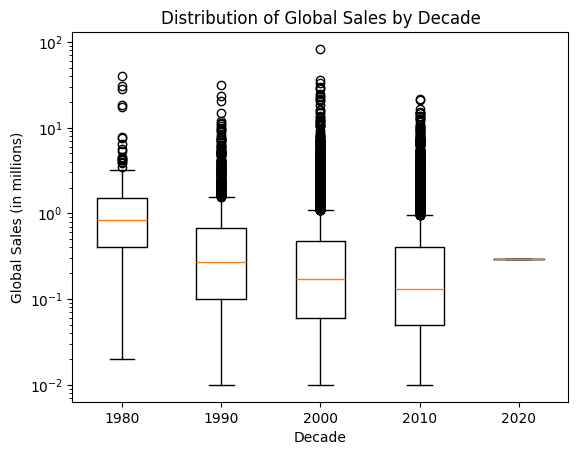

In [93]:
#What decade produced the best selling games?
df['Decade'] = (df['Year_of_Release']//10)*10
best_selling_games = df.groupby("Decade")['Global_Sales'].apply(list)

plt.boxplot(best_selling_games, labels = best_selling_games.index.astype(int))
plt.yscale('log')
plt.xlabel('Decade')
plt.ylabel('Global Sales (in millions)')
plt.title('Distribution of Global Sales by Decade')
plt.show()

In [94]:
df[df['Decade'] == 2020]['Global_Sales']

5936    0.29
Name: Global_Sales, dtype: float64

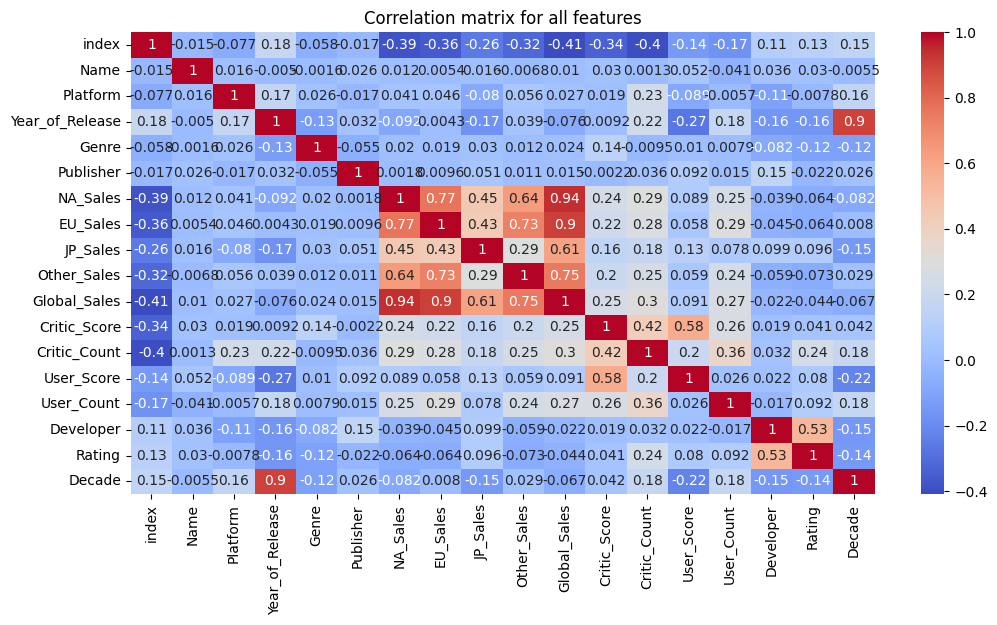

In [121]:
#WHAT FEATURES CORRELATE WITH HIGH USER SCORE?
df['User_Score'] = pd.to_numeric(df['User_Score'], errors= 'coerce')
le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].astype('category')
        df[column] = le.fit_transform(df[column].cat.codes.replace(-1,np.nan))

#calculate the correlation matrix
correcation_matrix = df.corr()


#visualisation 
plt.figure(figsize=(12,6))
sns.heatmap(correcation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation matrix for all features')
plt.show()

/var/folders/ky/wtg1vw412sz5kfbftp83kvn40000gn/T/ipykernel_20832/946266173.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  video_games_df["Year_of_Release"] = video_games_df['Year_of_Release'].astype(int)


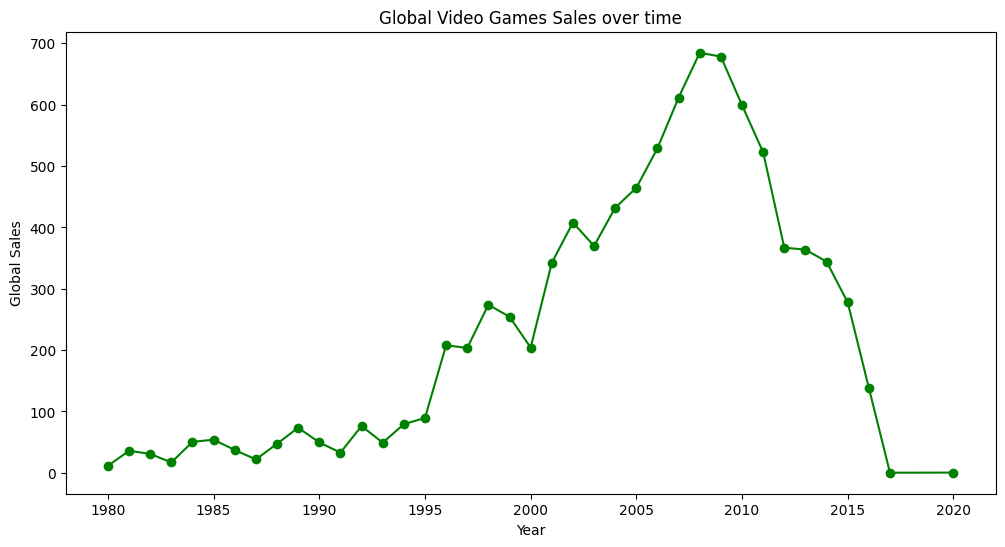

In [60]:
#EXAMINE HOW VIDEO GAMES HAVE CHANGED OVER THE YEARS.
video_games_df = df.dropna(subset=['Year_of_Release'])

video_games_df["Year_of_Release"] = video_games_df['Year_of_Release'].astype(int)
yearly_sales = video_games_df.groupby('Year_of_Release')["Global_Sales"].sum()

#ploting
plt.figure(figsize=(12,6))
yearly_sales.plot(kind = 'line', color = 'green', marker = 'o')
plt.title('Global Video Games Sales over time')
plt.xlabel('Year')
plt.ylabel('Global Sales')
plt.show()

<Figure size 1600x600 with 0 Axes>

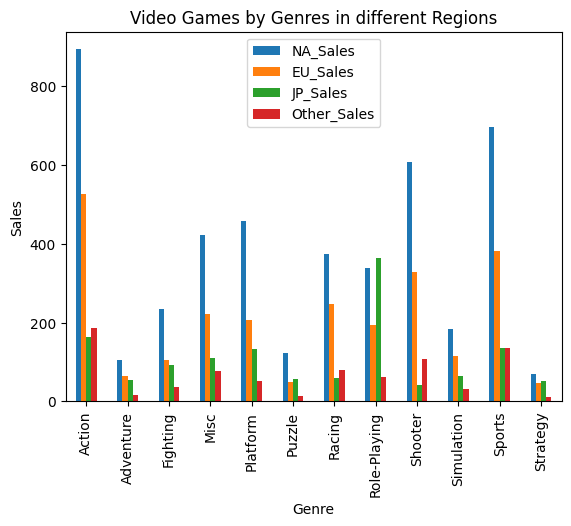

In [82]:
#COMPARE THE POPULARITY OF GENRES OR PLATFORMS ACROSS DIFFERENT REGIONS.
region_genre_sales= df.groupby('Genre')[['NA_Sales', 'EU_Sales', 'JP_Sales' , 'Other_Sales']].sum()


#ploting
plt.figure(figsize=(16,6))
region_genre_sales.plot(kind = 'bar')
plt.title('Video Games by Genres in different Regions')
plt.xlabel('Genre')
plt.ylabel('Sales')
plt.show()
